In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [3]:
df_2020 = pd.read_csv('data_3x3/delta_table_2020_3x3.csv')
df_2021 = pd.read_csv('data_3x3/delta_table_2021_3x3.csv')

In [4]:
df_2020.columns

Index(['delta_years', 'system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'bare_sparse_vegetation', 'built_up', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo', 'class_label', 'geometry', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1',
       'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1',
       'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1',
       'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1',
       'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1',
       'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0',
       'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0',
       'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0',
       'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1',
       'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1',
       'B7_m1_p1', 'B8_m1_p1', '

In [5]:
print(*(column for column, type in zip(df_2020.columns, df_2020.dtypes) if type == "string"))

.geo geometry


In [6]:
# df_2020 = df_2020.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", *[name for name in df_2021.columns if "B2_" in name or "B3_" in name or "B4_" in name], "x", "y"])
df_2020 = df_2020.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y", "class_label"])
df_2020 = df_2020.fillna(df_2020.mean())

# df_2021 = df_2021.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", *[name for name in df_2021.columns if "B2_" in name or "B3_" in name or "B4_" in name], "x", "y"])
df_2021 = df_2021.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y", "class_label"])
df_2021.drop(df_2021[df_2021["delta_years"] == 5].index, inplace=True)
df_2021 = df_2021.fillna(df_2021.mean())

In [7]:
# B1, B9, B10

In [8]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
# excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

# df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
# df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'tree_cover',
    'grassland',
    'cropland',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation'
]

# sel_col = excluded_bands
# df_2020 = df_2020[sel_col]
# df_2021 = df_2021[sel_col]

In [9]:
df_2020.columns

Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
       'B5_p0_p1', 'B6_p0_p1',

In [10]:
len(df_2020.columns)

88

In [11]:
def add_spectral_indices(df):
    # Base (unsuffixed) features + any suffixes inferred from B4_<suffix> columns
    suffixes = []
    # suffixes = [col.split("B4_", 1)[1] for col in df.columns if "B4_" in col]
    suffixes.append("")

    for suffix in suffixes:
        print(suffix)
        suffix_part = f"_{suffix}" if suffix else ""

        b2 = f"B2{suffix_part}"
        b3 = f"B3{suffix_part}"
        b4 = f"B4{suffix_part}"
        b8 = f"B8{suffix_part}"
        b11 = f"B11{suffix_part}"

        # Only create features when all required source columns for that index exist
        if all(col in df.columns for col in [b4, b8]):
            ndvi_name = f"NDVI_{suffix}" if suffix else "NDVI"
            df[ndvi_name] = (df[b8] - df[b4]) / (df[b8] + df[b4] + 1e-8)

        if all(col in df.columns for col in [b2, b4, b8]):
            evi_name = f"EVI_{suffix}" if suffix else "EVI"
            df[evi_name] = 2.5 * ((df[b8] - df[b4]) / (df[b8] + 6 * df[b4] - 7.5 * df[b2] + 1 + 1e-8))

        if all(col in df.columns for col in [b8, b11]):
            ndbi_name = f"NDBI_{suffix}" if suffix else "NDBI"
            df[ndbi_name] = (df[b11] - df[b8]) / (df[b11] + df[b8] + 1e-8)

        if all(col in df.columns for col in [b3, b8]):
            ndwi_name = f"NDWI_{suffix}" if suffix else "NDWI"
            df[ndwi_name] = (df[b3] - df[b8]) / (df[b3] + df[b8] + 1e-8)

        if all(col in df.columns for col in [b3, b11]):
            mndwi_name = f"MNDWI_{suffix}" if suffix else "MNDWI"
            df[mndwi_name] = (df[b3] - df[b11]) / (df[b3] + df[b11] + 1e-8)

    return df


# df_2020 = add_spectral_indices(df_2020)
# df_2021 = add_spectral_indices(df_2021)

In [12]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [13]:
df_2020.columns

Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
       'B5_p0_p1', 'B6_p0_p1',

In [14]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
# X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
# X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[target_labels]

In [15]:
X_train.columns, y_train.columns

(Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
        'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1',
        'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
        'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
        'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
        'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
        'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
        'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
        'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
        'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
        'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
        'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
        'B5_p0_p1', 'B6_p0_p1', 'B7_p0_p1', 'B8_p0_p1', 'B11_p1_p1',
        'B12_p1_p1', 'B2_p1_p1', 'B3_p1_p1

In [16]:
X_train.shape

(2286815, 88)

In [17]:
import xgboost as xgb

def _predict_multioutput_xgb_with_dmatrix(model, X):
    dX = xgb.DMatrix(X)
    preds = [est.get_booster().predict(dX) for est in model.estimators_]
    return np.column_stack(preds)

def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    if (
        isinstance(model, MultiOutputRegressor)
        and isinstance(model.estimator, XGBRegressor)
    ):
        y_train_pred = _predict_multioutput_xgb_with_dmatrix(model, X_train)
        y_test_pred = _predict_multioutput_xgb_with_dmatrix(model, X_test)
    else:
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

models = {
    # "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    # "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    # "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    # "SVR": Pipeline([
    #     ("scaler8239", StandardScaler()),
    #     ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1)))
    # ]),
    # "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=226,
                                                 learning_rate=0.033161675945190996,
                                                 random_state=42,
                                                 max_depth=8,
                                                 gamma=0.4287949729173641,
                                                 min_child_weight=8,
                                                 reg_alpha=0.006540138176385826,
                                                 reg_lambda=0.3389647419056726,
                                                 colsample_bytree=0.678024823943575,
                                                 subsample=0.8950857758926167,
                                                 device='cuda',
                                                 n_jobs=-1,
                                                 ),
                                    n_jobs=-1
                                    ),
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- XGBoost ---
Train R2: 0.8213 | Test R2: 0.7835
Train RMSE: 0.1299 | Test RMSE: 0.1461



In [19]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,XGBoost,0.129856,0.146137,0.821287,0.783538


In [20]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.361756,0.436823
built_up,0.373298,0.436750
grassland,0.121936,0.287627
cropland,0.107914,0.294333
bare_sparse_vegetation,0.023710,0.119634
water,0.011278,0.099440


,True_Dominant_Class,Pred_Dominant_Class,Match
0,built_up,built_up,True
1,built_up,built_up,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


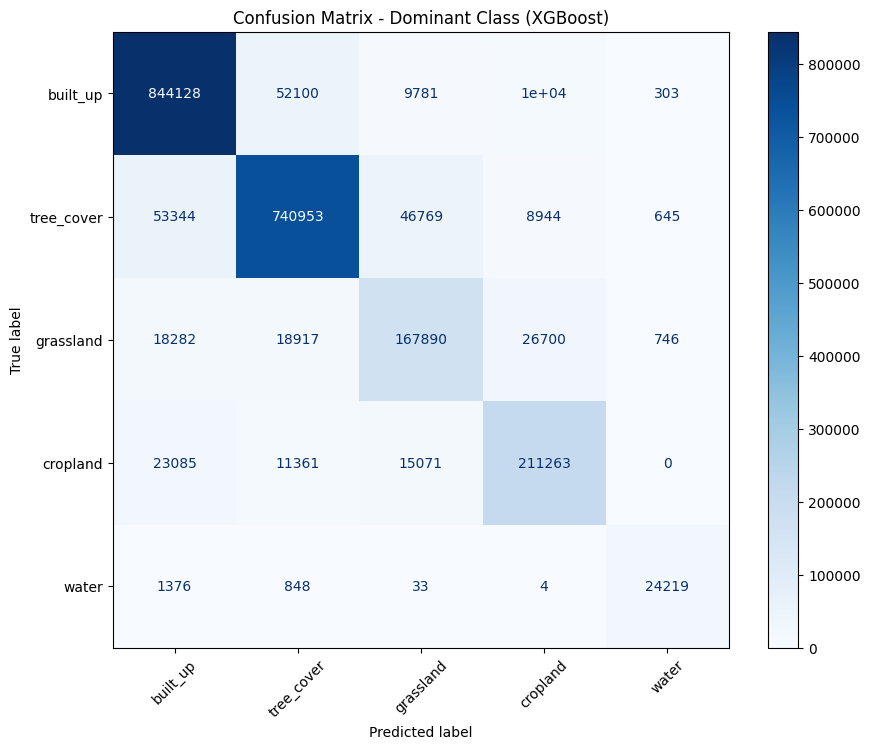

Overall Dominant Class Accuracy: 0.8695


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    # 'vegetation',
    'built_up',
    'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation',
    'water'
]

best_model_name = "XGBoost"
y_pred_array = _predict_multioutput_xgb_with_dmatrix(models[best_model_name], X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")

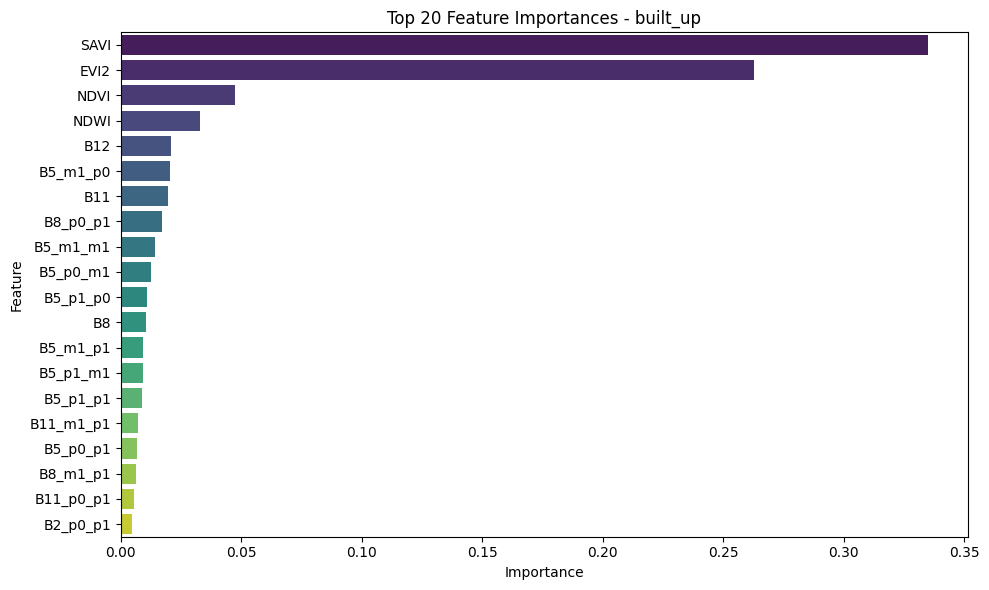

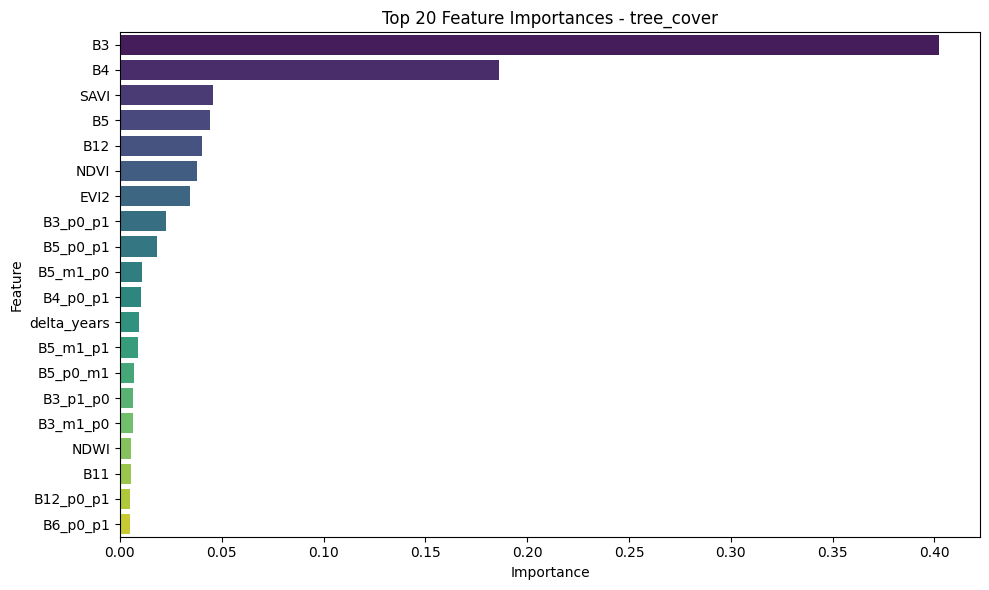

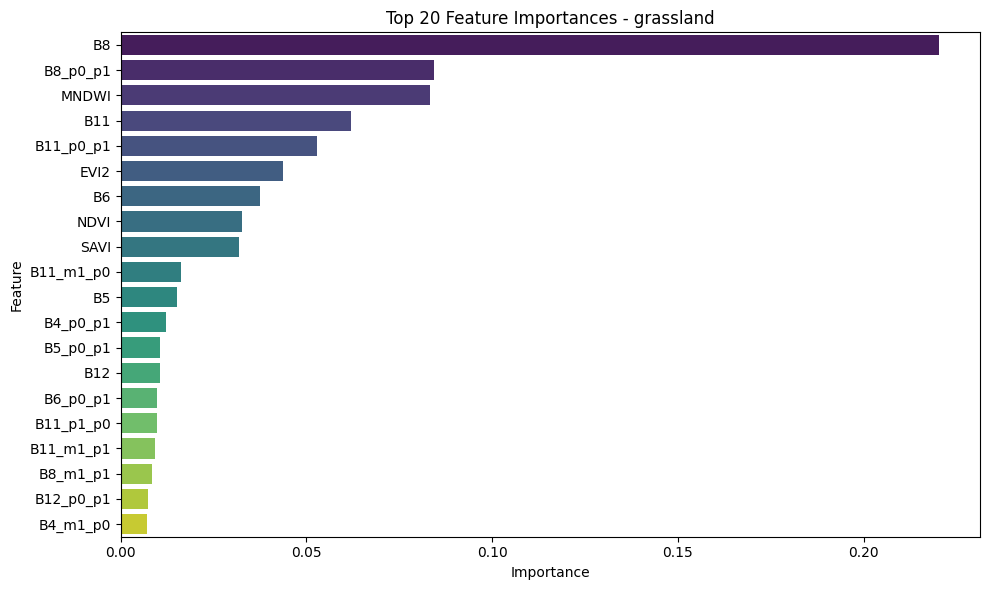

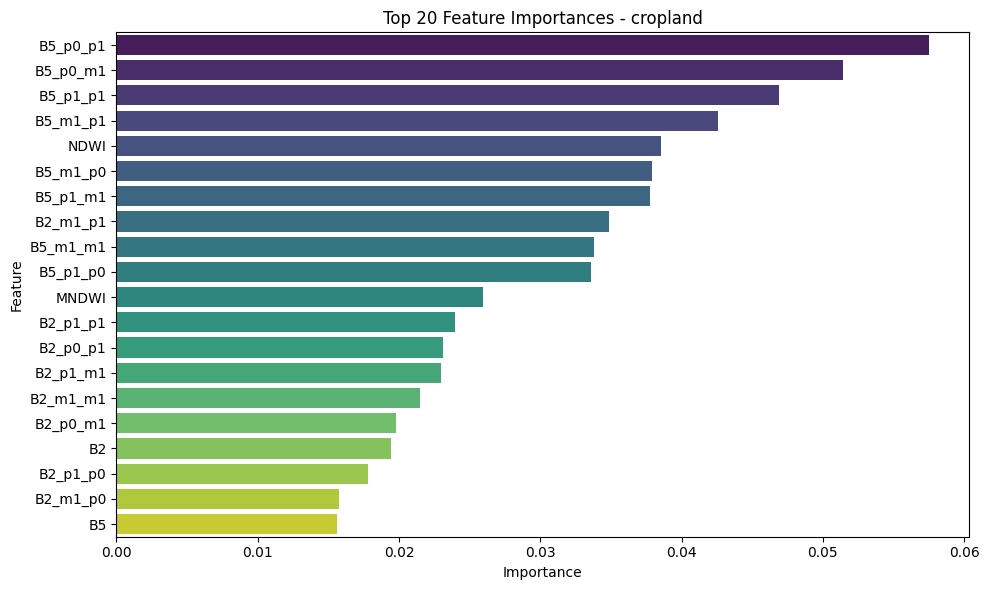

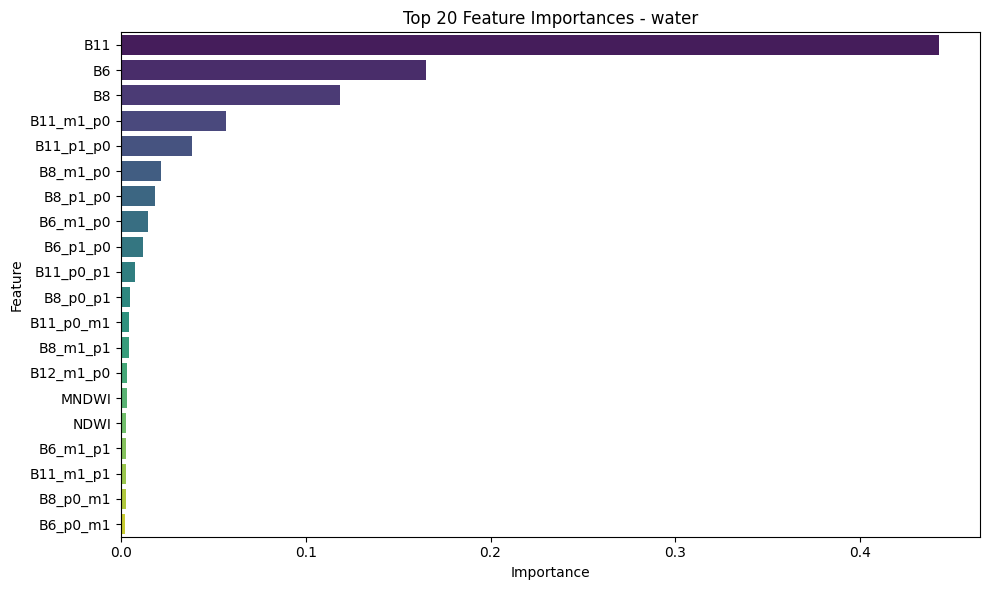

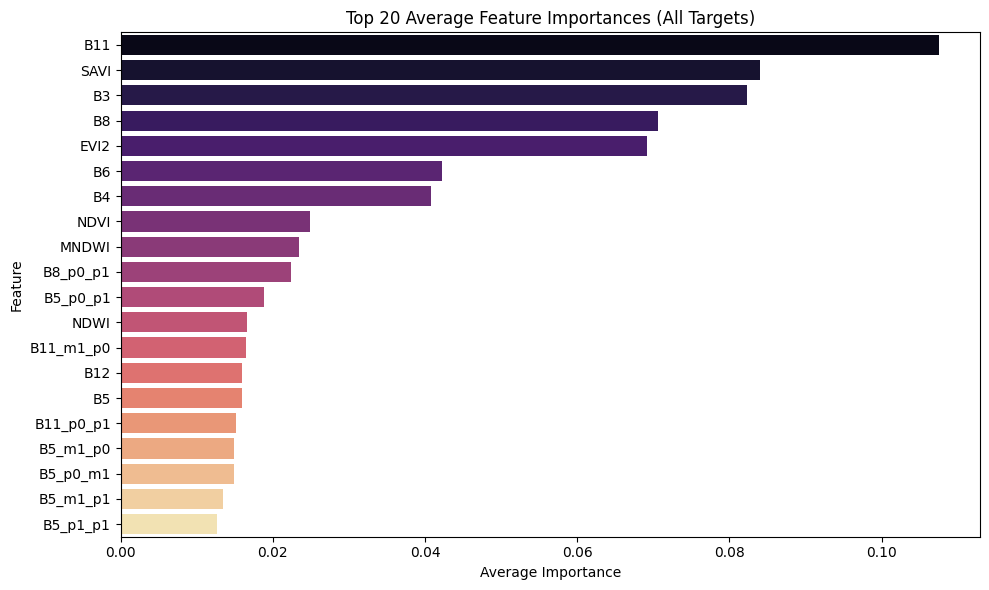

In [22]:
# Plot XGBoost feature importances (per target + average)
required_vars = ["models", "X_train", "target_labels"]
missing = [var for var in required_vars if var not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}. Run the training/setup cells first.")

xgb_model = models["XGBoost"]
if not hasattr(xgb_model, "estimators_"):
    raise ValueError("XGBoost model is not fitted yet. Run the model training cell first.")

feature_names = X_train.columns.to_list()
top_n = 20

importances_by_target = {
    target_labels[i]: est.feature_importances_
    for i, est in enumerate(xgb_model.estimators_)
}

importances_target_1 = importances_by_target[target_labels[0]]
importances_target_2 = importances_by_target[target_labels[1]]
avg_importances = np.mean(np.vstack(list(importances_by_target.values())), axis=0)

for label, importances in importances_by_target.items():
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
    plt.title(f"Top {top_n} Feature Importances - {label}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

avg_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": avg_importances
}).sort_values("importance", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_importance_df, x="importance", y="feature", hue="feature", palette="magma", legend=False)
plt.title(f"Top {top_n} Average Feature Importances (All Targets)")
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Some code to save and load the XGBoost Model

In [24]:
from pathlib import Path
import pickle

model_name = "XGBoost"
if model_name not in models:
    raise ValueError(f"Model '{model_name}' not found in `models`. Train it first.")

trained_model = models[model_name]

output_dir = Path("artifacts")
output_dir.mkdir(parents=True, exist_ok=True)
model_path = output_dir / "xgboost_multioutput.pkl"

with model_path.open("wb") as f:
    pickle.dump(trained_model, f)

print(f"Saved model to: {model_path.resolve()}")

Saved model to: /home/macedmo/git/machine-learning-final-project-ws2025/dashboard/artifacts/xgboost_multioutput.pkl


In [ ]:
from pathlib import Path
import pickle

model_path = Path("artifacts") / "xgboost_multioutput.pkl"
if not model_path.exists():
    raise FileNotFoundError(f"Model file not found: {model_path.resolve()}")

with model_path.open("rb") as f:
    loaded_xgb_model = pickle.load(f)

print(f"Loaded model from: {model_path.resolve()}")
print(f"Loaded model type: {type(loaded_xgb_model)}")

# Optional quick sanity check
sample_preds = loaded_xgb_model.predict(X_test.head(5))
print(f"Sanity check predictions shape: {sample_preds.shape}")